In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# hypothesis testing
from scipy.stats import jarque_bera, spearmanr
from scipy.stats import kruskal

# randomforest classifier for predict unknown value
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# geospace coding
import geopandas as gpd
from shapely.geometry import Point
from sklearn.neighbors import BallTree


pd.set_option('display.max_rows', None)

We brought the dataset from the Collaborative Work file of cleaning **Data Preprocessing**, then I combined dummies features into each aligned features such as **School District** and **Flooring Type**. Due to assigned field (I was in Location part of data cleaning), we will do additional cleaning and analyzing the housing dataset.

- That combined dataset is the one the final model will use, so Explanatory Data Analysis (EDA) describes the actual modeling data. It examines relationships between your location features and features created by other team members.

- Exploratory data analysis was conducted after the feature-engineering and preprocessing work from all team members was combined. Therefore, the distributions and relationships shown in the EDA reflect the final cleaned modeling dataset rather than the original raw dataset.

- Records with missing values in selected features and observations identified as extreme outliers were removed during preprocessing.

- **Interpretation caution:** The EDA reflects the final filtered modeling sample. Missing records and extreme observations were removed during team preprocessing, so rare or high-end properties may be underrepresented.

In [ ]:
df = pd.read_csv('/content/cleaned_data_dummies.csv')
print(df.shape)
df.head()

(47560, 26)


,ViewYN,PoolPrivateYN,ClosePrice,Latitude,Longitude,LivingArea,CountyOrParish,AttachedGarageYN,ParkingTotal,BathroomsTotalInteger,...,LotSizeSquareFeet,SalesTaxRate,UnemploymentRate,MortgageRate30Fixed,FedInterestRate,CPI,Age,LotDensity,FlooringType,SchoolDistrict
0,1,0,890000.0,34.180411,-118.342020,1434.0,Los Angeles,0,1,1.0,...,6473.0,0.1050,4.1,6.72,4.48,315.605,86.0,4.513947,Unknown,Burbank Unified
1,0,0,1138000.0,32.574359,-117.023836,2872.0,San Diego,1,6,3.0,...,5219.0,0.0775,4.1,6.72,4.48,315.605,25.0,1.817201,Unknown,Unknown
2,1,0,681877.0,33.725080,-117.222302,2824.0,Riverside,1,2,3.0,...,7000.0,0.0875,4.1,6.72,4.48,315.605,2.0,2.478754,Unknown,Unknown
3,1,0,900000.0,34.203479,-118.643567,2500.0,Los Angeles,1,2,3.0,...,8336.0,0.0975,4.1,6.72,4.48,315.605,55.0,3.334400,Unknown,Los Angeles Unified
4,0,0,862000.0,34.460368,-118.490755,2363.0,Los Angeles,1,2,3.0,...,11705.0,0.0975,4.1,6.72,4.48,315.605,31.0,4.953449,Unknown,Unknown


There are 338 features that has over listed compared to original dataset. We will check the additional features were included in the dataset.

In [ ]:
sorted(df.columns)

['Age',
 'AttachedGarageYN',
 'BathroomsTotalInteger',
 'BedroomsTotal',
 'CPI',
 'City',
 'ClosePrice',
 'CountyOrParish',
 'FedInterestRate',
 'FireplaceYN',
 'FlooringType',
 'GarageSpaces',
 'Latitude',
 'LivingArea',
 'Longitude',
 'LotDensity',
 'LotSizeSquareFeet',
 'MortgageRate30Fixed',
 'NewConstructionYN',
 'ParkingTotal',
 'PoolPrivateYN',
 'SalesTaxRate',
 'SchoolDistrict',
 'Stories',
 'UnemploymentRate',
 'ViewYN']

Let's break down the features into each data types for convenient afterwards.

In [ ]:
continuous= [
    "Age",
    "CPI",
    "ClosePrice",
    "FedInterestRate",
    "GarageSpaces",
    "Latitude",
    "LivingArea",
    "Longitude",
    "LotDensity",
    "LotSizeSquareFeet",
    "MortgageRate30Fixed",
    "SalesTaxRate",
    "UnemploymentRate"
]

discrete= [
    "BathroomsTotalInteger",
    "BedroomsTotal",
    "Stories",
    "GarageSpaces",
    "ParkingTotal"

]


categorical = [
    "City",
    "CountyOrParish",
    "FlooringType",
    "SchoolDistrict",
    "AttachedGarageYN",
    "FireplaceYN",
    "NewConstructionYN",
    "PoolPrivateYN",
    "ViewYN"
]



#1. Data Cleaning

## 1) Missing Values

Let's check if there is missing values after we combined the codings from teammates.

In [ ]:
df.isna().sum()

,0
ViewYN,0
PoolPrivateYN,0
ClosePrice,0
Latitude,0
Longitude,0
LivingArea,0
CountyOrParish,0
AttachedGarageYN,0
ParkingTotal,0
BathroomsTotalInteger,0


There are 11 explicit missing values on **Age** feature. As our team member Tara mentioned, we will drop the 11 missing values of **Age** feature.

In [ ]:
df = df.dropna()
df.isna().sum()

,0
ViewYN,0
PoolPrivateYN,0
ClosePrice,0
Latitude,0
Longitude,0
LivingArea,0
CountyOrParish,0
AttachedGarageYN,0
ParkingTotal,0
BathroomsTotalInteger,0


There is no explicit missing values. We will check if there is implicit missing values.

In [ ]:
df.dtypes

,0
ViewYN,int64
PoolPrivateYN,int64
ClosePrice,float64
Latitude,float64
Longitude,float64
LivingArea,float64
CountyOrParish,object
AttachedGarageYN,int64
ParkingTotal,int64
BathroomsTotalInteger,float64


All the numerical of continuous and discrete variables show float64 or int64 that implicit missing value does not exist. We will identify it on the categorical features.

In [ ]:
implicit_list = [
    "",
    " ",
    'Unknown',
    "unknown",
    "UNKNOWN",
    "N/A",
    "n/a",
    "None",
    "none",
    "NONE",
    "null",
    "NULL",
    "Null",
    "--",
    "-",
    'Missing',
    'missing',
    'MISSING'
]

for i in categorical:
  col = df[i]
  implicit = col[col.isin(implicit_list)].unique().tolist()

  print(f"{i}")
  print(implicit)
  print()

City
[]

CountyOrParish
[]

FlooringType
['Unknown']

SchoolDistrict
['Unknown']

AttachedGarageYN
[]

FireplaceYN
[]

NewConstructionYN
[]

PoolPrivateYN
[]

ViewYN
[]



There are implicit missing values in **FlooringType** and **SchoolDistrict** in Unknown value. We will deal with this when we explore those two features later.

## Explanatory Data Analysis

We will explore features that are considered as important features and contained implicit missing values as well.

### 1) Close Price

The close price of our target feature is the housing price that were sold. It is agreed upon sale amount between the buyer and seller.

In [ ]:
df["ClosePrice"].describe()

,ClosePrice
count,4.754900e+04
mean,1.044666e+06
std,7.093509e+05
min,2.400000e+05
25%,6.000000e+05
50%,8.375000e+05
75%,1.250000e+06
max,6.388000e+06


The overall close price is 1,026,571 dollars as mean, moving  typical close price is 830,000 dollars as median value. The maximum price is 6,375,000 dollars. The distribution would be right skewed pulling mean into upward due to luxury maximum price value.

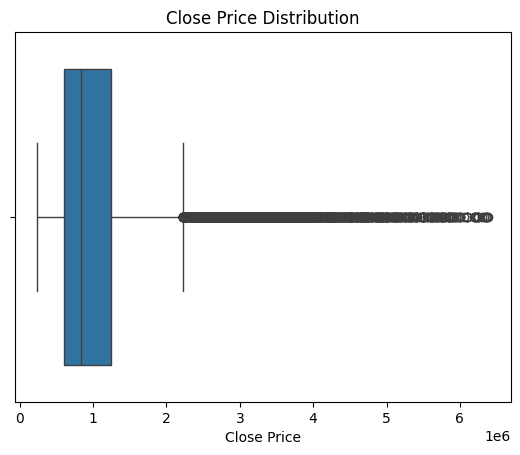

In [ ]:
sns.boxplot(x=df["ClosePrice"])
plt.title("Close Price Distribution")
plt.xlabel("Close Price")
plt.show()

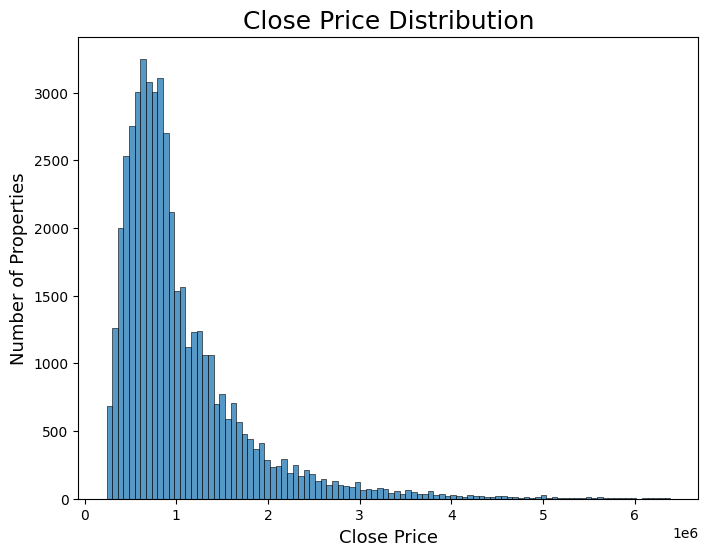

In [ ]:
plt.figure(figsize=(8,6))
sns.histplot(df["ClosePrice"], bins=100)
plt.title("Close Price Distribution", fontsize=18)
plt.xlabel("Close Price", fontsize=13)
plt.ylabel('Number of Properties', fontsize=13)
plt.show()

Most  of the sold prices are below 1 million dollars in 6 months in California. We identify the distribution is right skewed that correct measurement is median and IQR. The typical close price sold  830,000 dollars within 635,000 dollars in the range of 600,000 dollars to 1,235,000 dollars.

Above 2.19 million dollars, we considered potential upper outliers under boxplot rule containing several luxury high sold price.

### 2) Living Area

In [ ]:
df["LivingArea"].describe()

,LivingArea
count,47549.000000
mean,1950.894195
std,773.535706
min,752.000000
25%,1384.000000
50%,1782.000000
75%,2356.000000
max,5148.000000


The overall living area size is 1951 sqft, and typical living area size is 1782 sqft. The largest living area size is 5148 sqft, which the distribution would be right skewed that pulling mean to upward due to maximum living area size.

Under the IQR rule, the upper outlier bound is 3,814 sqft. Let's check the visualization.

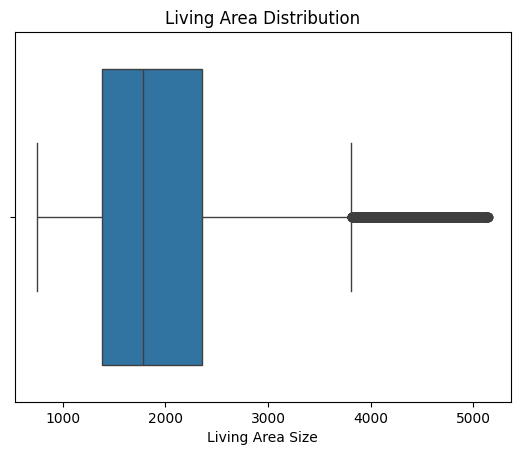

In [ ]:
sns.boxplot(x=df["LivingArea"])
plt.title("Living Area Distribution")
plt.xlabel("Living Area Size")
plt.show()

It is right skewed as we mentioned, and there are potential outliers above 3,814 sqft.

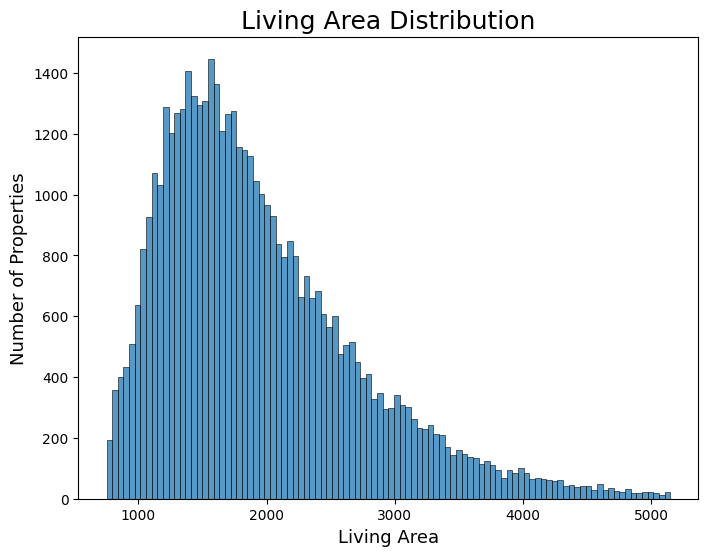

In [ ]:
plt.figure(figsize=(8,6))
sns.histplot(df["LivingArea"], bins=100)
plt.title("Living Area Distribution", fontsize=18)
plt.xlabel("Living Area", fontsize=13)
plt.ylabel('Number of Properties', fontsize=13)
plt.show()

Most of living area size is around **1,500 sqft**. We identify the distribution is right skewed. Due to right skewed, the typical sold house of living area size is **1,782 sqft** within **972 sqft** in the range of **1,384 sqft to 2,356 sqft.**

#### 1. Living Area & Close Price

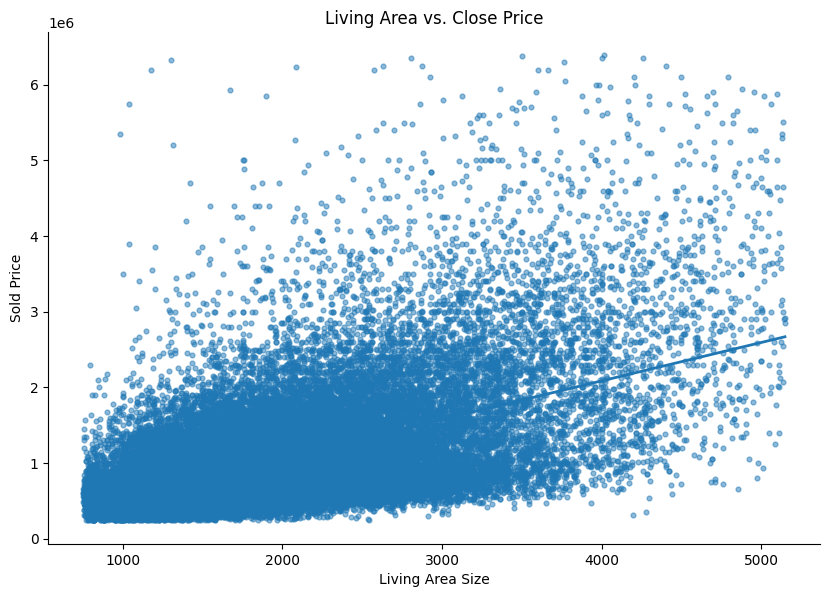

In [ ]:
sns.lmplot(
    data=df,
    x="LivingArea",
    y="ClosePrice",
    ci=False,
    scatter_kws={
        "alpha": 0.5,
        "s": 12
    },
    line_kws={
        "linewidth": 2
    },
    height=6,
    aspect=1.4
)

plt.title("Living Area vs. Close Price")
plt.xlabel("Living Area Size")
plt.ylabel("Sold Price")
plt.show()

The relationship between living area and sold price is positive trend that if living area increase, the price increase as well. The shape is linear.

In [ ]:
# statistically check correlation between price and living area
rho, p = spearmanr(df["ClosePrice"], df["LivingArea"])
print(f"rho is {rho}")
print(f"p-value is {p}")

rho is 0.4656898833017726
p-value is 0.0


It shows statistically significant that moderate positive association between living area and close price with p-value likely 0.0 with less  than 0.05. **This suggests that larger properties generally sell for higher prices, although living area alone does not fully explain differences in sale prices.**

### 3) Bedrooms

In [ ]:
df["BedroomsTotal"].describe()

,BedroomsTotal
count,47549.000000
mean,3.468128
std,0.855248
min,2.000000
25%,3.000000
50%,3.000000
75%,4.000000
max,6.000000


In [ ]:
df["BedroomsTotal"].value_counts()


,count
BedroomsTotal,
3.0,20922
4.0,16341
2.0,5082
5.0,4612
6.0,592


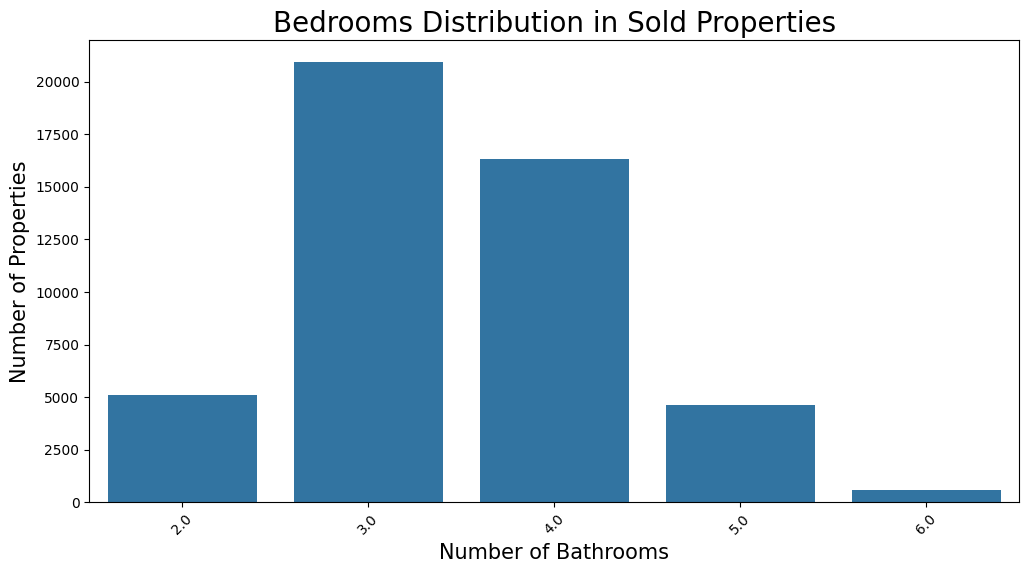

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(x="BedroomsTotal", data = df)
plt.xticks(rotation=45)
plt.title('Bedrooms Distribution in Sold Properties', fontsize = 20)
plt.xlabel('Number of Bathrooms', fontsize = 15)
plt.ylabel('Number of Properties', fontsize = 15)
plt.show()

Most of the sold properties has **3 beds** about 2,100 houses and **4 beds** about 1,600 houses during Dec 2024 to May 2025 in California.

#### 1. Bedrooms vs. Close Price

Let's identify the relationship between bedrooms and sold price.

In [ ]:
(df
 .groupby(["BedroomsTotal"])["ClosePrice"]
 .agg(
     count = "count",
     min = "min",
     q1 = lambda x : x.quantile(0.25),
     median = "median",
     q3 = lambda x : x.quantile(0.75),
     max = "max"
 )
).sort_values("median", ascending=False)

,count,min,q1,median,q3,max
BedroomsTotal,,,,,,
6.0,592,358000.0,850000.00,1231250.0,1875000.0,5900000.0
5.0,4612,265000.0,783723.25,1200000.0,1900000.0,6300000.0
4.0,16341,240000.0,675000.00,950000.0,1450000.0,6388000.0
3.0,20922,240000.0,551062.50,775000.0,1070000.0,6350000.0
2.0,5082,240000.0,435000.00,645025.0,864375.0,6200000.0


The table is sorted by median price across number of bedrooms over close price. Since close price is right skewed, let's focus on the median close price.

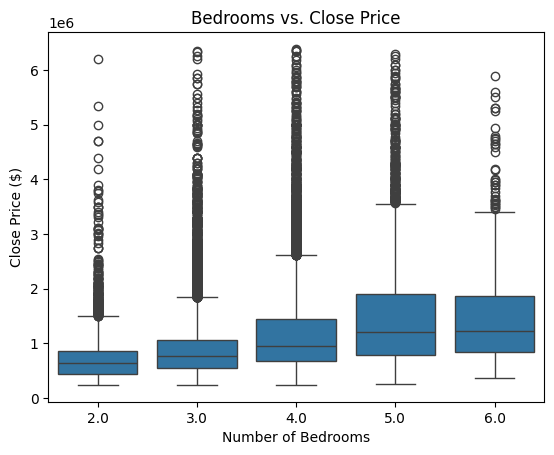

In [ ]:
sns.boxplot(x="BedroomsTotal", y="ClosePrice", data = df)
plt.title("Bedrooms vs. Close Price")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Close Price ($)")
plt.show()

- The highest median close price generally increases as the number of bedrooms increases from approximately **\$645,000**  for **2 bedroom** properties to about **\$1.23 million** for **6 bedroom** properties.

- The **6 bedrooms** category contained only **592** properties, considerably fewer than the other groups, so its median and quartiles should be interpreted more cautiously.

- There is overlapped close price below \$1 million.

- Price variability generally increase for properties with more bedrooms. **5 bedrooms** properties had the largest IQR, approximately **\$1.12 million**, indicating that median of 5 beds sale prices covered wide range.

- All bedrooms have potential outliers including valid high value or luxury properties, and right skewed.

In [ ]:
rho, p = spearmanr(
    df["BedroomsTotal"],
    df["ClosePrice"]
)

print(f"Spearman rho: {rho:.3f}")
print(f"p-value: {p:.3g}")

Spearman rho: 0.326
p-value: 0


- Spearman’s rank correlation showed a statistically significant, with weak-moderate correlation coefficient 0.326. There is **positive association between the number of bedrooms and closing price**.

- Because the p-value is below the significance level of 0.05, we reject the null hypothesis of no monotonic association.

### 4) Bathrooms

Let's explore bathrooms feature and identify its distribution and relationship between close price.

In [ ]:
# summary for number of bathrooms
df["BathroomsTotalInteger"].describe()

,BathroomsTotalInteger
count,47549.000000
mean,2.526131
std,0.908847
min,1.000000
25%,2.000000
50%,2.000000
75%,3.000000
max,6.000000


The overall number of  bathrooms in sold houses are **2.5**, and **2** bathrooms are typical number in sold houses in California from Dec 2024 to May 2025. The maximum number of bathroom is 6.

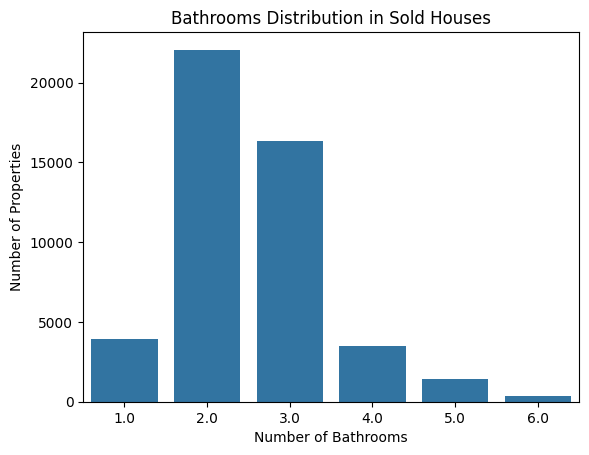

In [ ]:
# Distribution of number of bathrooms
sns.countplot(x="BathroomsTotalInteger", data = df)
plt.title("Bathrooms Distribution in Sold Houses")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Number of Properties")
plt.show()

Most of the sold houses have** 2 or 3 bathrooms** over 15000 properties in California.

#### 1) Batrhooms vs. Close Price

Let's identify the relationship between number of bathrooms and close price in California.

In [ ]:
# group by number of bathrooms showing median and IQR of close price
(df
 .groupby(["BathroomsTotalInteger"])["ClosePrice"]
 .agg(
     count = "count",
     min = "min",
     q1 = lambda x : x.quantile(0.25),
     median = "median",
     q3 = lambda x : x.quantile(0.75),
     max = "max"
 )
).sort_values("median", ascending=False)

,count,min,q1,median,q3,max
BathroomsTotalInteger,,,,,,
6.0,356,699000.0,2123750.0,2900000.0,3707500.0,6000000.0
5.0,1403,421000.0,1520000.0,2247500.0,3093875.0,6375000.0
4.0,3462,290000.0,954839.5,1455000.0,2248500.0,6388000.0
3.0,16363,250000.0,670000.0,929000.0,1399000.0,6350000.0
2.0,22062,240000.0,521925.0,750000.0,1000000.0,6325000.0
1.0,3903,240000.0,480000.0,665000.0,805000.0,4195000.0


- As the **number of bathroom increase, the median close price increase** approximately from **1 bathroom of \$665,000** to **6 bathrooms of \$2,900,000**.

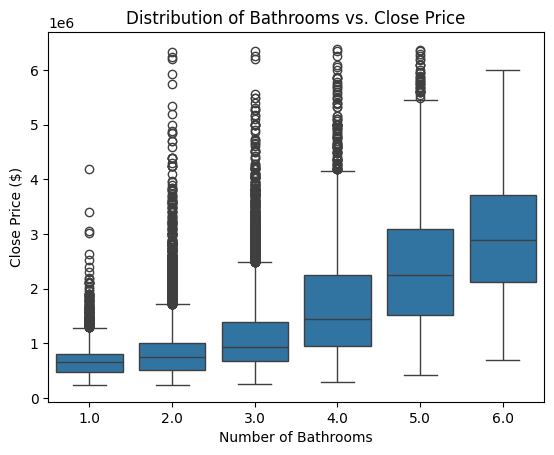

In [ ]:
# show distribution boxplot of relationship
sns.boxplot(x="BathroomsTotalInteger", y="ClosePrice", data = df)
plt.title("Distribution of Bathrooms vs. Close Price")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Close Price ($)")
plt.show()

- There are at least one IQR box that distinguished, and **it suggests that there might be association with bathrooms and close price.**

- 6 bathrooms contain **356 properties **have been sold in California, and need to be cautious interpretation.

- Price variability generally increase for properties with more bedrooms. 4, 5, and 6 batrhooms have large IQR covered.

- All bathroomss have potential outliers including valid high value or luxury properties, and right skewed.

In [ ]:
rho, p = spearmanr(
    df["BathroomsTotalInteger"],
    df["ClosePrice"]
)

print(f"Spearman rho: {rho:.3f}")
print(f"p-value: {p:.3g}")

Spearman rho: 0.423
p-value: 0


- Spearman’s rank correlation showed a statistically significant **positive association between the number of bathrooms and closing price**.

- Because the p-value is below the significance level of 0.05, we reject the null hypothesis of no monotonic association.

### 5) Lot Size

Let's explore the lot size in California that have been sold from Dec 2024 to May 2025.

In [ ]:
# summary for lot size
df["LotSizeSquareFeet"].describe()

,LotSizeSquareFeet
count,47549.000000
mean,12179.253846
std,20600.630588
min,2046.000000
25%,5750.000000
50%,7255.000000
75%,10000.000000
max,217800.000000


The overall lot size for sold houses in California is 12,179 sqft, and typical lot size is **7255 sqft**. The maximum lot size is** 217,800 sqft**. The mean value is pulled upward due to minor large lot size.

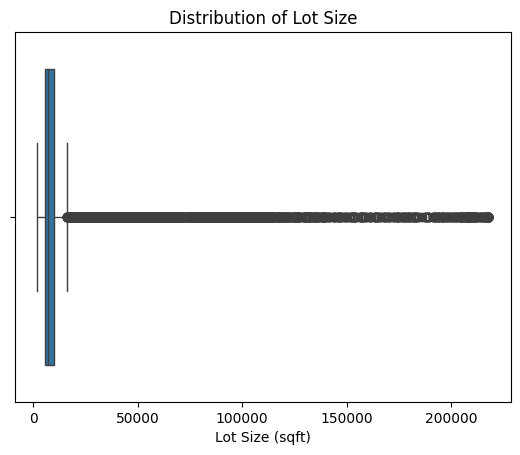

In [ ]:
# Boxplot distribution of lot size
sns.boxplot(x=df["LotSizeSquareFeet"])
plt.title("Distribution of Lot Size")
plt.xlabel("Lot Size (sqft)")
plt.show()

The distribution is** highly right skewed** with variability of lot size across California. There are many potential outliers of lot size with upper bound of **16,375 sqft**.

Text(0, 0.5, 'Number of Properties')

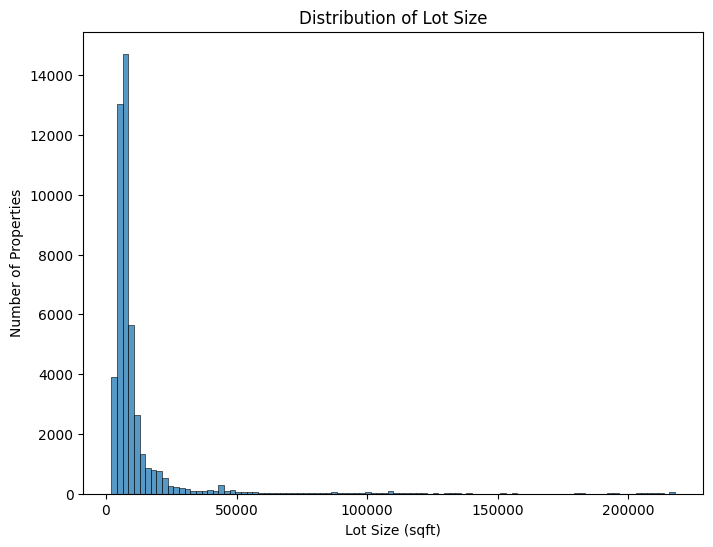

In [ ]:
# histogram distribution of lot size
plt.figure(figsize=(8,6))
sns.histplot(x=df["LotSizeSquareFeet"], bins = 100)
plt.title("Distribution of Lot Size")
plt.xlabel("Lot Size (sqft)")
plt.ylabel("Number of Properties")


Most of lot sizes in sold houses are around below 10,000 sqft. Due to highly right skewed, the median of **typical lot size is 7255 sqft within 4,250 sqft from 5,750 sqft to 10,000 sqft**.

#### 1. Lot Size vs. Close Price

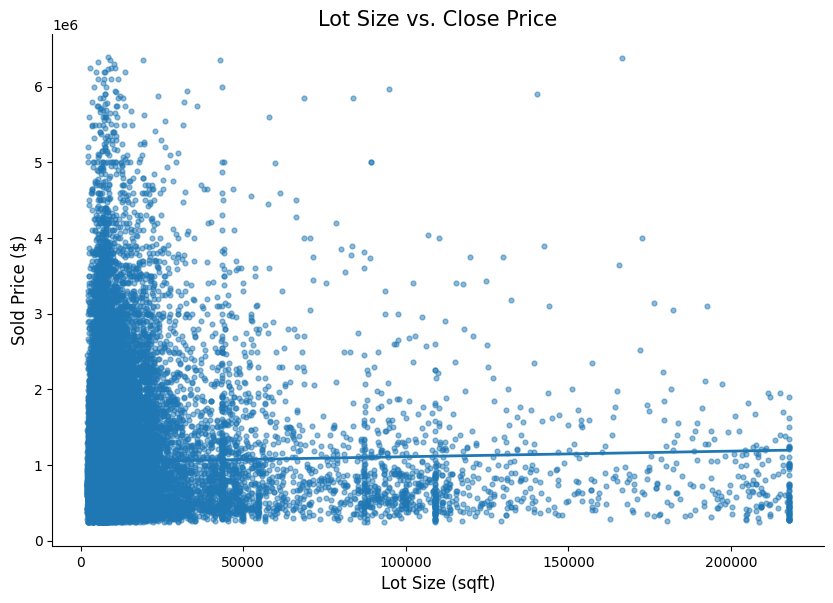

In [ ]:
# scatter plot relationship of lot size vs. close price
sns.lmplot(
    x="LotSizeSquareFeet",
    y="ClosePrice",
    data = df,
    ci = False,
    scatter_kws = {
        "alpha": 0.5,
        "s": 12
    },
    line_kws = {"linewidth":2},
    height = 6,
    aspect = 1.4
)
plt.title("Lot Size vs. Close Price", fontsize = 15)
plt.xlabel("Lot Size (sqft)", fontsize=12)
plt.ylabel("Sold Price ($)",fontsize=12)
plt.show()

- As the lot size increase, the sold price slightly increase as positive way.

- There are couple potential outliers.

In [ ]:
# spearman hypothesis test for correlation
rho, p = spearmanr(
    df["LotSizeSquareFeet"],
    df["ClosePrice"]
)

print(f"Spearman rho: {rho:.3f}")
print(f"p-value: {p:.3g}")



Spearman rho: 0.078
p-value: 1.72e-65


- The spearman correlation coefficient shows 0.078 that  statistically significant weak positive monotonic association between lot size and close price.

- The p-value of almost 0 is less than 0.05 that there is a monotonic association between lot size and closing price.

### 6) Age

Let's explore the age of property that has been built from the year 2025, then identify the relationship with close price.

In [ ]:
# lists for age values
df["Age"].value_counts()

,count
Age,
2.0,1426
71.0,1079
37.0,996
21.0,920
38.0,879
72.0,855
22.0,845
70.0,843
20.0,836


There are many unique values of ages, and there are many values that are less than 100 properties. We will group by year term as 0-5, 6-10, 11-20, 21-40, 41-70, 70+ for better visualization and understanding the distribution.

In [ ]:
def age_split(ages):
    if ages<=5:
        return "0-5"

    elif ages > 5 and ages<=10:
        return "6-10"

    elif ages>10 and ages <=20:
        return "11-20"

    elif ages>20 and ages<=40:
        return "21-40"

    elif ages>40 and ages<=70:
        return "41-70"

    elif ages>70:
        return "70+"

df["AgeGroup"] = df["Age"].apply(age_split)

df["AgeGroup"].value_counts()

,count
AgeGroup,
41-70,17114
21-40,12507
70+,10872
0-5,2969
11-20,2614
6-10,1473


There are many properties that are built over 21 years old. There are couple properties that were built recent years as well.

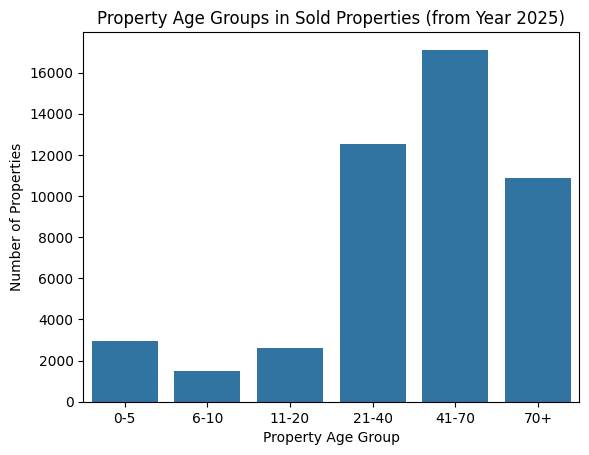

In [ ]:
# distribution of property ages group
sns.countplot(x="AgeGroup", data = df , order=["0-5","6-10","11-20","21-40","41-70","70+"])
plt.title("Property Age Groups in Sold Properties (from Year 2025)")
plt.xlabel("Property Age Group")
plt.ylabel("Number of Properties")
plt.show()

The most of ages that were sold is over 21 years old. Newer properties were less common especially 6 to 10 years old. Overall, the sold property dataset contains more middle aged and older homes, rather than newest properties.

#### 1. Age vs. Close Price

Let's check the relationship between age groups and close price with sorted by median price.

In [ ]:
# list of median price group by age
(df.groupby("AgeGroup")["ClosePrice"]
 .agg(
     count="count",
     min = "min",
     q1= lambda x:x.quantile(0.25),
     median = "median",
     q3 = lambda x:x.quantile(0.75),
     IQR = lambda x:x.quantile(0.75) - x.quantile(0.25),
     max = "max"
 )
).sort_values("median", ascending=False)

,count,min,q1,median,q3,IQR,max
AgeGroup,,,,,,,
41-70,17114,240000.0,655000.0,915000.0,1314750.0,659750.0,6350000.0
70+,10872,240000.0,667000.0,855000.0,1226000.0,559000.0,6350000.0
6-10,1473,265000.0,610000.0,812500.0,1310000.0,700000.0,5970000.0
21-40,12507,240000.0,550000.0,769000.0,1250000.0,700000.0,6388000.0
11-20,2614,255000.0,539225.0,725000.0,1188972.0,649747.0,6100000.0
0-5,2969,260000.0,546364.0,650000.0,850000.0,303636.0,6375000.0


- The most typical expensive sold price is year** 41 - 70 old** with **\$915,000** within **\$659,750 from \$655,000 to \$1,314,750.** It has wide range covered as variety of prices sold.

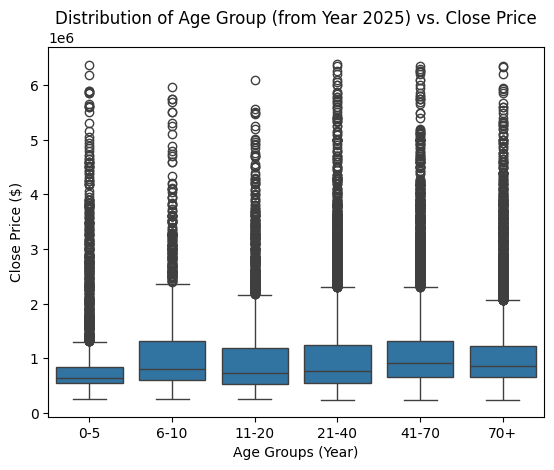

In [ ]:
# boxplot distribution for ages group vs. close price
sns.boxplot(x="AgeGroup", y="ClosePrice", data=df, order=["0-5","6-10","11-20","21-40","41-70","70+"])
plt.title("Distribution of Age Group (from Year 2025) vs. Close Price")
plt.xlabel("Age Groups (Year)")
plt.ylabel("Close Price ($)")
plt.show()

- Closing price distribution is overlapped across all ages groups and IQR boxes are not distinguished. This suggests that **there are not likely have association with ages and close price.**

- Every age groups contain high price at upper whisker and variety of prices.

- There is no relationship of increasing or decreasing terms.

In [ ]:
age_order = ["0-5", "6-10", "11-20", "21-40", "41-70", "70+"]

groups = [
    df.loc[df["AgeGroup"] == age_group, "ClosePrice"]
    for age_group in age_order
]

h_stat, p_value = kruskal(*groups)

print(f"Kruskal-Wallis H statistic: {h_stat:.3f}")
print(f"p-value: {p_value:.3e}")

Kruskal-Wallis H statistic: 947.897
p-value: 1.143e-202


- The null hypothesis the distribution of close price is same across all age groups. Since the p-value is less than 0.05, we reject the null hypothesis.

- We found statistically significant differnce in closing price distribution across property age groups with coefficient 947.9. **This indicates property age group is weak associated with close price.**

- Although median prices differ across age groups, the substantial overlap in price distributions suggests that **age group alone has limited ability to explain closing price variation.**

### 7) County

Let's explore the county distribution across California has been sold.

In [ ]:
# list of all county in data
county_count = df["CountyOrParish"].value_counts()

county_count

,count
CountyOrParish,
Los Angeles,11995
Riverside,8641
San Bernardino,5871
Orange,5149
San Diego,5096
Contra Costa,2314
Alameda,2127
Ventura,1704
San Luis Obispo,792


There are some properties were filtered out in terms of outliers from previous file from **Data Preprocessing**.
Let's visualize first.

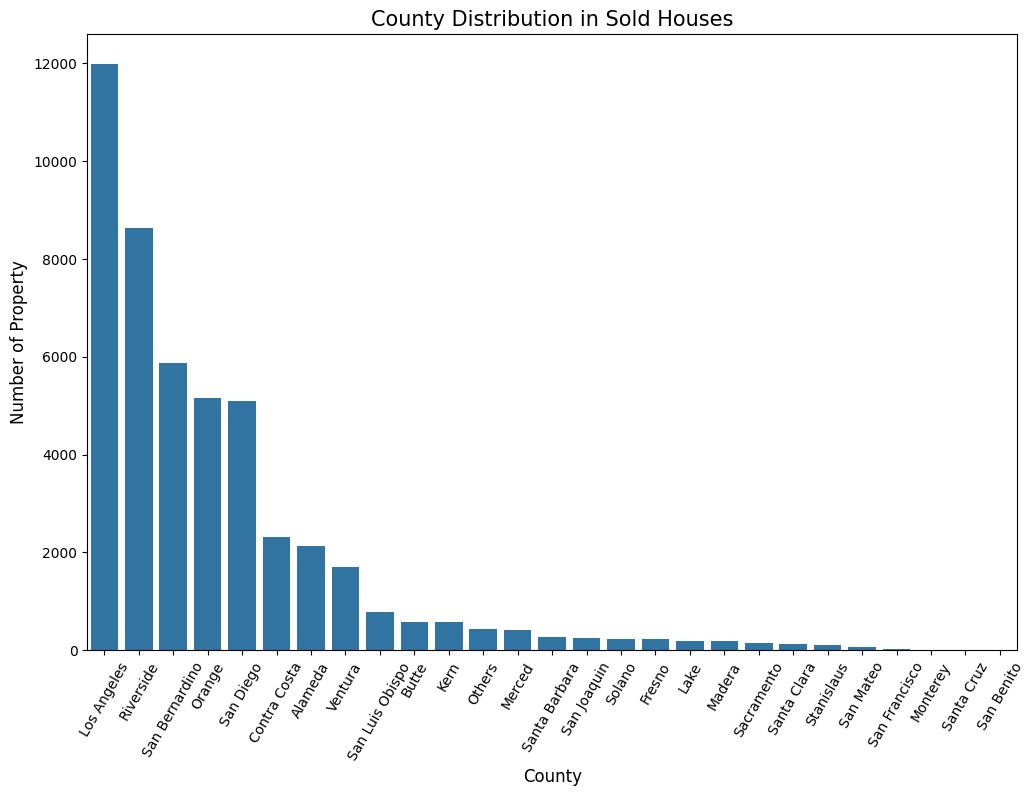

In [ ]:
# Barplot distribution for county
plt.figure(figsize=(12,8))
sns.countplot(x="CountyOrParish", data = df, order = county_count.index)
plt.xticks(rotation=60)
plt.title("County Distribution in Sold Houses", fontsize=15)
plt.xlabel("County",fontsize = 12)
plt.ylabel("Number of Property", fontsize = 12)
plt.show()

Most of the properties that were sold are in Los Angeles, Riverside, San Bernardino, then so forth.



Let's identify small sample sizes of counties.

In [ ]:
# show list of counties have less than 100 rows
other_counties_index= county_count[
    county_count <= 100
].index


other_counties_index

Index(['Stanislaus', 'San Mateo', 'San Francisco', 'Monterey', 'Santa Cruz',
       'San Benito'],
      dtype='object', name='CountyOrParish')

Those are the list of counties that have less than 100 properties.

#### 1. County vs. Close Price

Let's explore the relationship between county and close price, sorting by median top to bottom.

In [ ]:
group_county_price = (df.groupby("CountyOrParish")["ClosePrice"]
 .agg(
     count="count",
     min = "min",
     q1= lambda x:x.quantile(0.25),
     median = "median",
     q3 = lambda x:x.quantile(0.75),
     IQR = lambda x:x.quantile(0.75) - x.quantile(0.25),
     max = "max"
 )
).sort_values("median", ascending=False)

group_county_price

,count,min,q1,median,q3,IQR,max
CountyOrParish,,,,,,,
Santa Clara,135,825000.0,1332500.0,1775000.0,2460000.0,1127500.0,5175000.0
San Mateo,57,800000.0,1200000.0,1560000.0,1908000.0,708000.0,3350000.0
Orange,5149,395000.0,1090000.0,1375000.0,1840000.0,750000.0,6388000.0
Alameda,2127,250000.0,917500.0,1300000.0,1695000.0,777500.0,5300000.0
San Francisco,23,510000.0,986500.0,1180000.0,1377500.0,391000.0,3050000.0
San Diego,5096,279000.0,815000.0,1040000.0,1500000.0,685000.0,6350000.0
Ventura,1704,350000.0,799375.0,934000.0,1286000.0,486625.0,6375000.0
Los Angeles,11995,250000.0,750000.0,930000.0,1340000.0,590000.0,6350000.0
San Luis Obispo,792,309000.0,725000.0,925000.0,1225000.0,500000.0,4675000.0


- **The most expensive county** of median sold price is **Santa Clara with \$1,775,000 within \$1,127,500 in the range from \$1,332,500 to \$2,460,000**. Even though it contains less properties sold compare to other counties, it is still expensive sold, and covers variety of price range. **But, we need to be cautious of this interpretation due to less properties compare to others.**

- The top rank 4 of expensive median sold price mignt have expensive of luxury houses that has less number of properties sold than Los Angeles.  

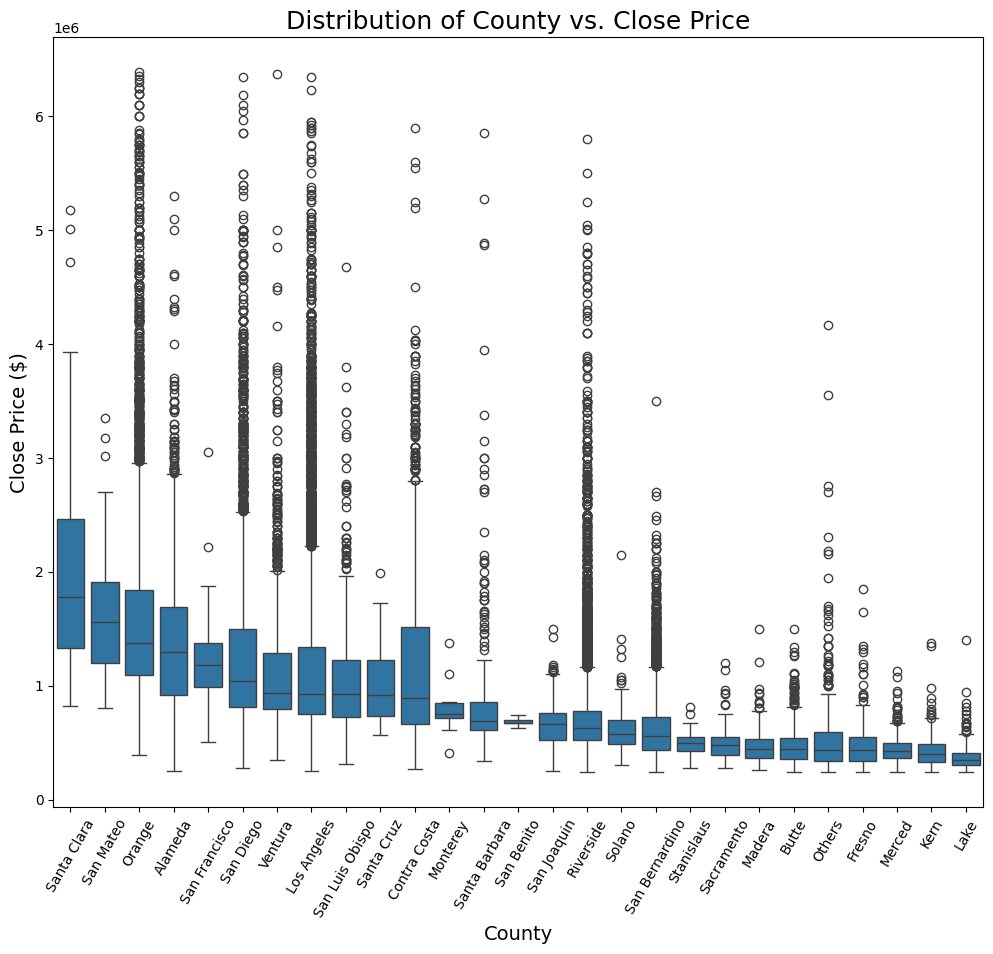

In [ ]:
# boxplot distribution for county vs. close price
plt.figure(figsize=(12, 10))
sns.boxplot(x="CountyOrParish", y="ClosePrice", data=df, order = group_county_price.index)
plt.xticks(rotation=60)
plt.title("Distribution of County vs. Close Price", fontsize = 18)
plt.xlabel("County", fontsize=14)
plt.ylabel("Close Price ($)", fontsize= 14)
plt.show()

- If we consider the box IQR from top and bottom that were sorted by median price, it is not overlapped, and **it might suggest that county has association with close price.**

- The properties that were sold many properties cover variety of sold prices including potential outliers that are upper whisker.

To reduce sparsity and improve model stability, counties with fewer than 100 properties were regrouped into an **Others** category. This helps prevent the model from learning unreliable patterns from categories with very small sample sizes.

The **Others** is included, **'Mendocino', 'Glenn', 'Tehama', 'Tulare', 'Mariposa', 'Imperial',
       'Kings', 'Yuba', 'Placer', 'Sonoma', 'Marin', 'Sutter', 'Napa',
       'Shasta', 'Calaveras', 'Tuolumne', 'El Dorado', 'Yolo', 'Trinity',
       'Plumas', 'Siskiyou', 'Nevada', 'Colusa', 'Amador', 'Mono', 'Humboldt',
       'Del Norte', 'Inyo', 'Foreign Country', 'Other State'** from previous file of **Data Preprocessing**.

In [ ]:
# group counties that less than 100 properties into others
df["CountyOrParish2"] = df["CountyOrParish"].replace(
    other_counties_index,
    "Others"
)

df["CountyOrParish2"].value_counts()

,count
CountyOrParish2,
Los Angeles,11995
Riverside,8641
San Bernardino,5871
Orange,5149
San Diego,5096
Contra Costa,2314
Alameda,2127
Ventura,1704
San Luis Obispo,792


### 8) Flooring Type

Let's identify the **Flooring Type** features including unknown values.

In [ ]:
flooring = df['FlooringType'].value_counts()
flooring



,count
FlooringType,
Unknown,17623
Carpet,14304
Laminate,5006
Tile,4363
Wood,2500
Vinyl,2052
SeeRemarks,770
Stone,428
Concrete,275


The unknown of implicit missing value is higher than other values.

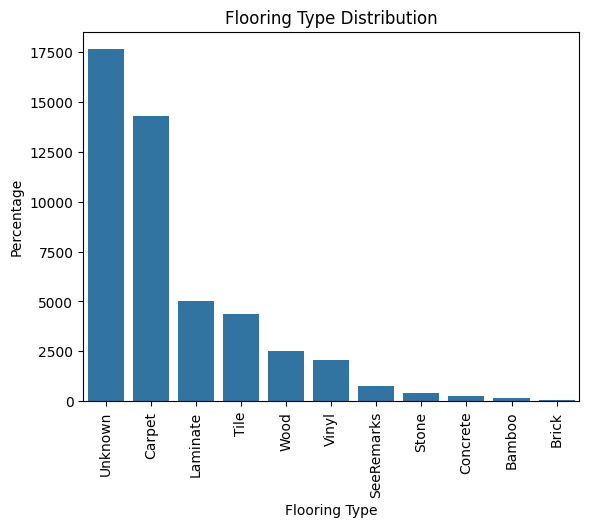

In [ ]:
sns.barplot(x=flooring.index, y=flooring.values)
plt.title('Flooring Type Distribution')
plt.xticks(rotation=90)
plt.xlabel('Flooring Type')
plt.ylabel('Percentage')
plt.show()


There are explicit missing values called Unknown, we will use RandomForest Classifier to predict the Unknown value. We will use the predictors of the features that has no missing values of **ClosePrice, LivingArea, BathroomsTotalInteger, BathroomsTotalInteger, GarageSpaces, Longitude,** and **Latitude**.

In [ ]:
#Call out the copy for test and replace it to original data
df2 = df.copy()

#Call predictors for Flooring Type
predictors=["LivingArea", "BathroomsTotalInteger", "BathroomsTotalInteger", "GarageSpaces", "Longitude", "Latitude"]

le = LabelEncoder()

#Change Unknown values into explicit missing value (Since we know there are no explicit missing values, it is okay to use it.)
df2["FlooringType"]= df2["FlooringType"].replace("Unknown", np.nan)

#Divide into no explicit missing values and missing values(Unknown).
known = df2[df2["FlooringType"].notna()]
unknown=df2[df2["FlooringType"].isna()]

#Change into numerical form
known["FlooringType"]=le.fit_transform(known["FlooringType"])


x_train,x_test,y_train,y_test=train_test_split(known[predictors], known["FlooringType"], test_size=0.2, random_state=42)

#Randomforest perform predicting Flooring Type missing values using predictors of no explicit missing values of Flooring Type.
clf=RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(x_train, y_train)

y_pred=clf.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)

#Predict the missing values of Flooring Type
predict_flooring=clf.predict(unknown[predictors])

#Reverse numerical into categorical feature.
predict_flooring_labels=le.inverse_transform(predict_flooring)

#Check
accuracy

/tmp/ipykernel_2614/2126228842.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  known["FlooringType"]=le.fit_transform(known["FlooringType"])


0.4463748747076512

The predict accuracy is 0.44 that it is not practical to use this method, because the unknown value might contain meaning values, and we don't know exact values as well. We will leave as unknown instead.




In [ ]:
flooring_percentages = df['FlooringType'].value_counts(normalize=True) *100
flooring_percentages

,proportion
FlooringType,
Unknown,37.062819
Carpet,30.082652
Laminate,10.528087
Tile,9.175798
Wood,5.257734
Vinyl,4.315548
SeeRemarks,1.619382
Stone,0.900124
Concrete,0.578351


- The carpet has the most contained sold properties across other floor types about 30%.

- The brick has the less contained sold properties less than 0.1%.

- We don't know what floor types are included in uknown value.



#### 1. Flooring Type vs. Close Price

In [ ]:
# group flooring type measuring median of close price
group_floor_price = (df.groupby("FlooringType")["ClosePrice"]
 .agg(
     count="count",
     min = "min",
     q1= lambda x:x.quantile(0.25),
     median = "median",
     q3 = lambda x:x.quantile(0.75),
     IQR = lambda x:x.quantile(0.75) - x.quantile(0.25),
     max = "max"
 )
).sort_values("median", ascending=False)

group_floor_price

,count,min,q1,median,q3,IQR,max
FlooringType,,,,,,,
Stone,428,345000.0,1132500.0,1682500.0,2450000.0,1317500.0,6350000.0
Wood,2500,245000.0,825000.0,1250000.0,1850000.0,1025000.0,6388000.0
Brick,43,280000.0,863250.0,1100000.0,1796500.0,933250.0,6200000.0
Bamboo,185,315500.0,785000.0,1015000.0,1490000.0,705000.0,5475000.0
Tile,4363,240000.0,675000.0,970000.0,1500000.0,825000.0,6300000.0
Carpet,14304,240000.0,600000.0,840000.0,1300000.0,700000.0,6000000.0
Vinyl,2052,240000.0,605000.0,831000.0,1175750.0,570750.0,4650000.0
SeeRemarks,770,240000.0,599213.5,811500.0,1241250.0,642036.5,4888888.0
Laminate,5006,240000.0,574200.0,795000.0,1075000.0,500800.0,5250000.0


- The most expensive floor type among sold houses is **Stone with \$1,682,500 within \$1,317,500 in the range of \$1,132,500 to \$2,450,000.**

- We need to be cautious interpreting this flooring type due to imbalance number of properties have been sold, and the unknown value is the most properties sold.



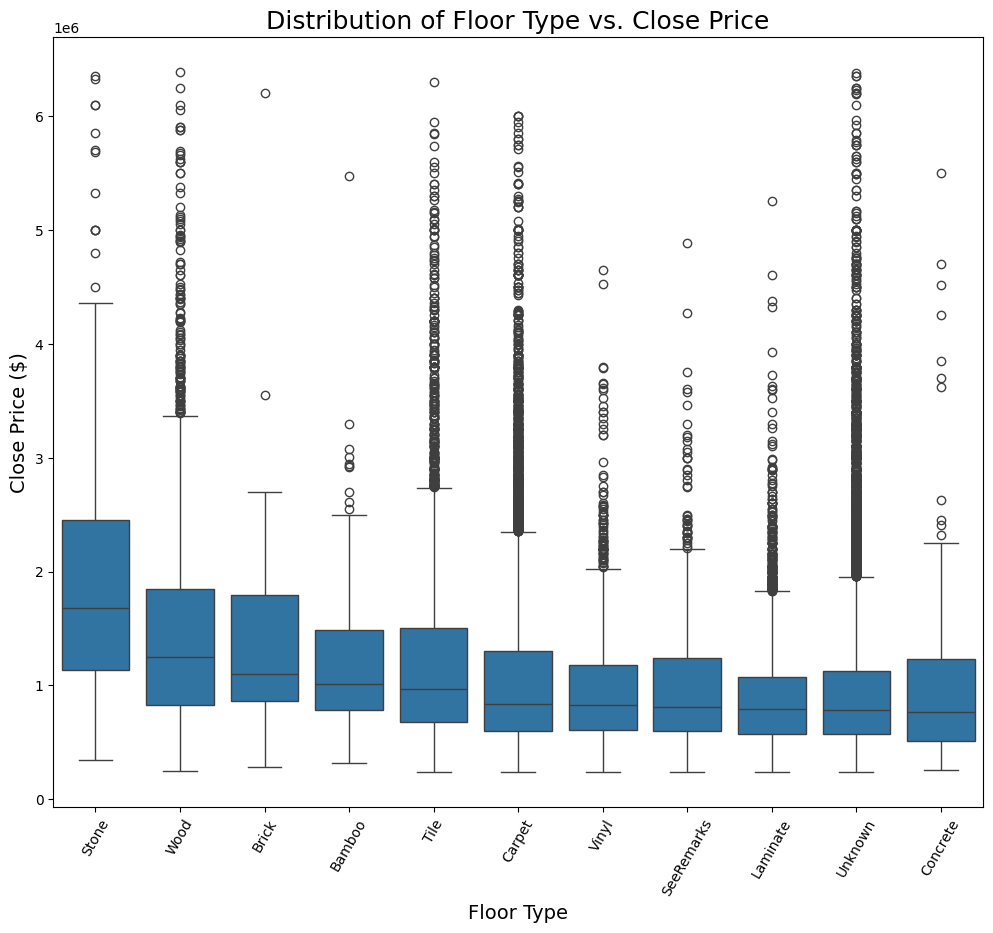

In [ ]:
# boxplot distribution for floor type vs. close price
plt.figure(figsize=(12, 10))
sns.boxplot(x="FlooringType", y="ClosePrice", data=df, order = group_floor_price.index)
plt.xticks(rotation=60)
plt.title("Distribution of Floor Type vs. Close Price", fontsize = 18)
plt.xlabel("Floor Type", fontsize=14)
plt.ylabel("Close Price ($)", fontsize= 14)
plt.show()

- Under the IQR, there are overlapped around $1.2 million and **it might suggest that floor type and close price have weak association.**

- The floor types that have many sold properties contain variety of range close price including upper whiskers.

There are less than 1% of flooring type values. We consider that as outliers and group it in **Others**.

In [ ]:
other_floor_index = flooring_percentages[
    flooring_percentages < 1
].index

other_floor_index

Index(['Stone', 'Concrete', 'Bamboo', 'Brick'], dtype='object', name='FlooringType')

In [ ]:
df["FlooringType2"] = df["FlooringType"].replace(
    other_floor_index,
    "Others"
)

df["FlooringType2"].value_counts()

,count
FlooringType2,
Unknown,17623
Carpet,14304
Laminate,5006
Tile,4363
Wood,2500
Vinyl,2052
Others,931
SeeRemarks,770


### 9) School District

There was implicit missing values as Unknown in **School District**.
Let's check the unique values considering outliers.

In [ ]:
df["SchoolDistrict"].value_counts(normalize=True) * 100

,proportion
SchoolDistrict,
Unknown,23.783886
Los Angeles Unified,8.620581
San Diego City Unified,2.578393
Capistrano Unified,2.092578
Desert Sands Unified,2.025279
Corona-Norco Unified,1.669856
Palm Springs Unified,1.533155
Riverside Unified,1.499506
Hemet Unified,1.415382


The SchoolDistrict variable is highly imbalanced and sparse. The Unknown category represents approximately 23.8% of all observations, while most individual school districts account for less than 1% of the dataset. This high cardinality would produce many rare categories during encoding, increasing model complexity and the risk that the model memorizes district-specific patterns based on very small sample sizes. As a result, the feature may contribute to overfitting and may not generalize well to unseen properties. In addition, the large Unknown category should be interpreted as missing district information rather than as a meaningful geographic group.


Instead of using the high-cardinality SchoolDistrict variable, the number of schools located within two miles of each property can be used as a more compact proximity feature.

We will make a feature of count of schools that are within 2 miles in each property. This is numerical and does not require hundreds of sparse dummy variables, reducing model complexity and the risk of overfitting from rare district categories. It also provides a consistent measure of access to nearby schools for both training data and new properties. However, the feature measures school availability rather than school quality or district reputation.


The National Center for Education Statistics Public School File. The dataset provides the names and geographic coordinates of public schools in the United States.

**source**: https://nces.ed.gov/programs/edge/geographic/schoollocations

**file name**:  Public School File (29.0 MB), 2024 - 2025

In [ ]:
# Load school locations
df_schools = pd.read_excel(
    "/content/EDGE_GEOCODE_PUBLICSCH_2425.xlsx"
)

# Keep schools with only California
df_schools = df_schools[df_schools["STATE"]=="CA"]

df_schools.head()

,NCESSCH,LEAID,NAME,OPSTFIPS,STREET,CITY,STATE,ZIP,STFIP,CNTY,...,LON,CBSA,NMCBSA,CBSATYPE,CSA,NMCSA,CD,SLDL,SLDU,SCHOOLYEAR
5740,60000103278,600001,Vasquez High,6,33630 Red Rover Mine Rd.,Acton,CA,93510,6,6037,...,-118.215978,31080,"Los Angeles-Long Beach-Anaheim, CA",1,348,"Los Angeles-Long Beach, CA",627,06034,06023,2024-2025
5741,60000107534,600001,Meadowlark Elementary,6,3015 West Sacramento St.,Acton,CA,93510,6,6037,...,-118.185622,31080,"Los Angeles-Long Beach-Anaheim, CA",1,348,"Los Angeles-Long Beach, CA",627,06034,06023,2024-2025
5742,60000109444,600001,High Desert,6,3620 Antelope Woods Rd.,Acton,CA,93510,6,6037,...,-118.195128,31080,"Los Angeles-Long Beach-Anaheim, CA",1,348,"Los Angeles-Long Beach, CA",627,06034,06023,2024-2025
5743,60000210346,600002,California School for the Blind,6,500 Walnut Ave.,Fremont,CA,94536,6,6001,...,-121.965490,41860,"San Francisco-Oakland-Fremont, CA",1,488,"San Jose-San Francisco-Oakland, CA",614,06024,06010,2024-2025
5744,60000310347,600003,California School for the Deaf-Fremont,6,39350 Gallaudet Dr.,Fremont,CA,94538,6,6001,...,-121.963353,41860,"San Francisco-Oakland-Fremont, CA",1,488,"San Jose-San Francisco-Oakland, CA",614,06024,06010,2024-2025


check if there is missing values.

In [ ]:
df_schools.isna().sum()

,0
NCESSCH,0
LEAID,0
NAME,0
OPSTFIPS,0
STREET,0
CITY,0
STATE,0
ZIP,0
STFIP,0
CNTY,0


There is no missing values. We only need the information of school names, longitude, and latitude.

To create the **SchoolCount2Miles** feature, properties with valid latitude and longitude values were matched with California public school coordinates. A BallTree spatial search using the Haversine distance was used to efficiently identify schools located within a two-mile radius of each property. The number of nearby schools was then counted and added to the property dataset as a new numerical feature.

In [ ]:
# Keep only properties with valid coordinates
valid_property_mask = (
    df["Latitude"].notna()
    & df["Longitude"].notna()
)

valid_properties = df.loc[
    valid_property_mask,
    ["Latitude", "Longitude"]
]

# Convert property coordinates to radians
property_coordinates = np.radians(
    valid_properties[["Latitude", "Longitude"]]
    .to_numpy(dtype=float)
)

# Convert school coordinates to radians
valid_school = np.radians(
    df_schools[["LAT", "LON"]]
    .to_numpy(dtype=float)
)


In [ ]:
# build spatial search tree using school coordinates
tree = BallTree(
    valid_school,
    metric="haversine"
)

# 2 miles radius
earth_radius_miles = 3958.8
radius_radians = 2 / earth_radius_miles

# query schools around each property
nearby_school_indices = tree.query_radius(
    property_coordinates,
    r=radius_radians
)

# count schools within 2 miles
valid_properties["SchoolCount2Miles"] = [
    len(indices)
    for indices in nearby_school_indices
]

# add results back to original dataframe
df["SchoolCount2Miles"] = np.nan

df.loc[
    valid_properties.index,
    "SchoolCount2Miles"
] = valid_properties["SchoolCount2Miles"]

In [ ]:
df["SchoolCount2Miles"].describe()

,SchoolCount2Miles
count,47549.000000
mean,12.973038
std,10.289011
min,0.000000
25%,6.000000
50%,11.000000
75%,18.000000
max,94.000000


Overall, there are about 13 public schools around sold properties, and typical number of 11 schools are surrounded in 2 miles. There are properties that are 94 public schools within 2 miles.

In [ ]:
# list for school counts
df["SchoolCount2Miles"].value_counts()

,count
SchoolCount2Miles,
7.0,2412
8.0,2345
6.0,2316
9.0,2267
5.0,2266
10.0,2263
11.0,2225
4.0,2221
3.0,2018


Most properties are located near a relatively small number of schools, while properties with very high school counts occur much less frequently.

To improve interpretability and provide more stable group sizes, the school counts were grouped into broader proximity categories: no nearby schools, 1–5 schools, 6–10 schools, 11–20 schools, and 21 or more schools within two miles.

In [ ]:
def categorize_school_count(count):
    if pd.isna(count):
        return "Unknown"
    elif count == 0:
        return "No Schools"
    elif count <= 5:
        return "1-5 Schools"
    elif count > 5 and count <= 10:
        return "6-10 Schools"
    elif count > 10 and count <= 20:
        return "11-20 Schools"
    else:
        return "20+ Schools"


df["SchoolCountGroup"] = (
    df["SchoolCount2Miles"]
    .apply(categorize_school_count)
)


df["SchoolCountGroup"].value_counts()

,count
SchoolCountGroup,
11-20 Schools,15316
6-10 Schools,11603
1-5 Schools,10087
20+ Schools,9073
No Schools,1470


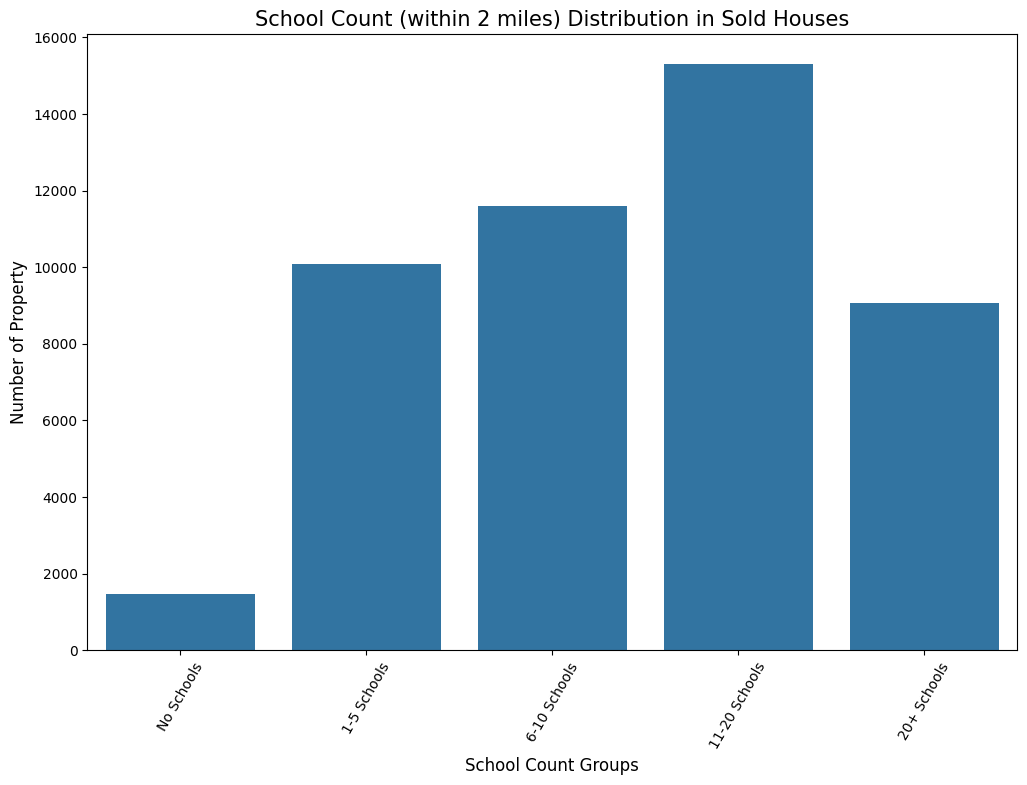

In [ ]:
school_group_order = [
    "No Schools",
    "1-5 Schools",
    "6-10 Schools",
    "11-20 Schools",
    "20+ Schools"]

# Barplot distribution for school count
plt.figure(figsize=(12,8))
sns.countplot(x="SchoolCountGroup", data = df, order=school_group_order)
plt.xticks(rotation=60)
plt.title("School Count (within 2 miles) Distribution in Sold Houses", fontsize=15)
plt.xlabel("School Count Groups",fontsize = 12)
plt.ylabel("Number of Property", fontsize = 12)
plt.show()

Most of the over 10,000 properties have 1 - 20 public schools around 2 miles in each property. More than 20 public schools are the 9,073 properties, and 1,470 properties do not involved public schools within 2 miles.

#### 1. School Count vs. Close Price

In [ ]:
group_school_count_price = (df.groupby("SchoolCountGroup")["ClosePrice"]
 .agg(
     count="count",
     min = "min",
     q1= lambda x:x.quantile(0.25),
     median = "median",
     q3 = lambda x:x.quantile(0.75),
     IQR = lambda x:x.quantile(0.75) - x.quantile(0.25),
     max = "max"
 )
).sort_values("median", ascending=False)

group_school_count_price

,count,min,q1,median,q3,IQR,max
SchoolCountGroup,,,,,,,
11-20 Schools,15316,240000.0,640000.0,881000.0,1299999.0,659999.0,6350000.0
20+ Schools,9073,240000.0,705000.0,860000.0,1160000.0,455000.0,5900000.0
6-10 Schools,11603,240000.0,590000.0,830000.0,1320000.0,730000.0,6250000.0
1-5 Schools,10087,240000.0,520797.5,740000.0,1285000.0,764202.5,6388000.0
No Schools,1470,240000.0,431000.0,592975.0,889750.0,458750.0,5000000.0


- Properties with **no schools** within two miles had the lowest median close price at approximately **\$592,975, with the middle 50% of prices ranging from \$431,000 to \$889,750.** This group also had the smallest number of observations, with only 1,470 properties, so its results should be interpreted cautiously.

- The highest median close price was found in **the 11–20 Schools group** at approximately **\$881,000. Its IQR ranged from \$640,000 to \$1,299,999,** showing that properties in this group covered a wide variety of sale prices.

- The **20+ Schools group** had a median price of approximately **\$860,000**, **with an IQR from \$705,000 to \$1,160,000.**

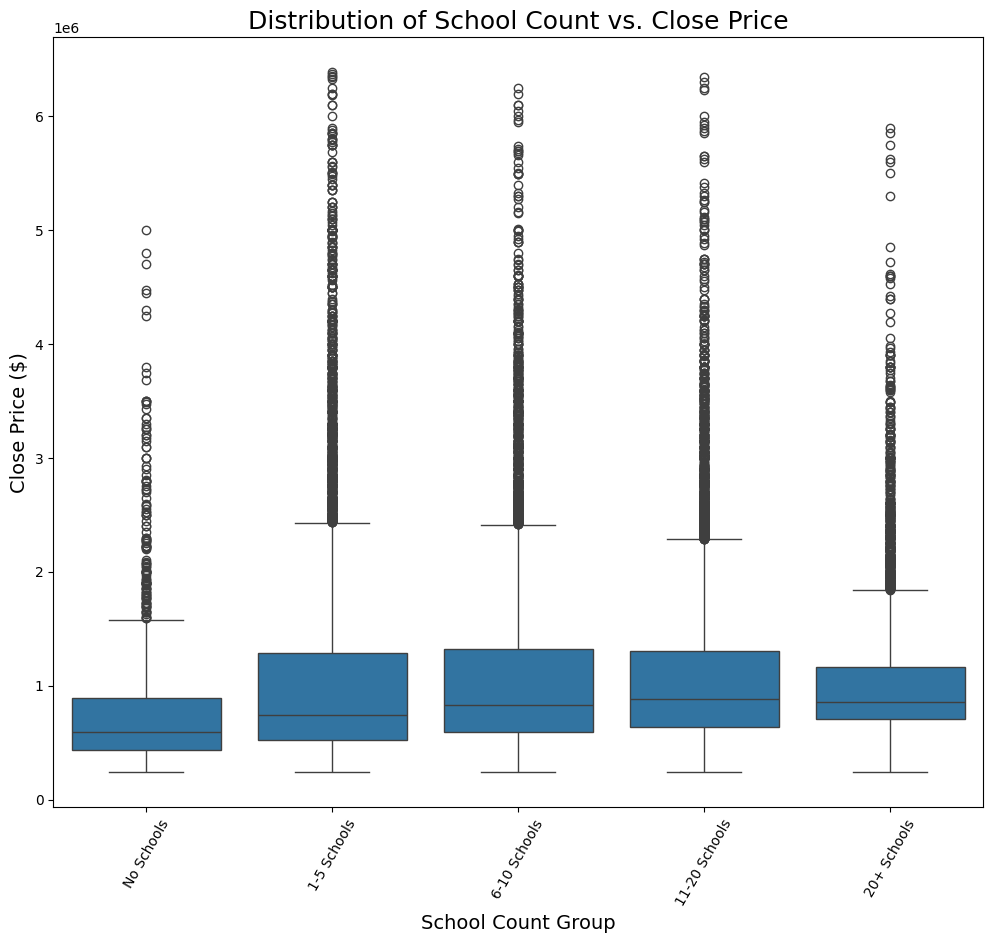

In [ ]:
# boxplot distribution for county vs. close price
plt.figure(figsize=(12, 10))
sns.boxplot(x="SchoolCountGroup", y="ClosePrice", data=df, order = school_group_order)
plt.xticks(rotation=60)
plt.title("Distribution of School Count vs. Close Price", fontsize = 18)
plt.xlabel("School Count Group", fontsize=14)
plt.ylabel("Close Price ($)", fontsize= 14)
plt.show()

- The plot may **suggest an less association between nearby school availability and close price, because the median price rises across the lower school-count groups.**

- However, the substantial overlap among the IQRs indicates that **school count alone does not strongly distinguish property prices.** Other factors, such as county, urban density, property size, neighborhood, and school quality, may also explain the observed differences.

# Feature Screening

As we explored the features in previous EDA, let's list of correlation between close price and other features.

We will exclude the raw **SchoolDistrict** due to:

- 227 categories
- About 24% unknown
- Many rare districts
- High risk of overfitting and sparse encoding

Instead, we will use **SchoolCountGroup** as categorical and **SchoolCount2Miles** as numerical features.

Additionally, we will use **CountyOrParish** instead of **City** due to:
- More stalbe and easier encode
- Less likey to overfit

In [ ]:
continuous= [
    "Age",
    "CPI",
    "FedInterestRate",
    "GarageSpaces",
    "Latitude",
    "LivingArea",
    "Longitude",
    "LotDensity",
    "LotSizeSquareFeet",
    "MortgageRate30Fixed",
    "SalesTaxRate",
    "UnemploymentRate"
]

discrete= [
    "BathroomsTotalInteger",
    "BedroomsTotal",
    "Stories",
    "GarageSpaces",
    "ParkingTotal",
    "SchoolCount2Miles"
]


categorical = [
    "CountyOrParish",
    "FlooringType",
    "AttachedGarageYN",
    "FireplaceYN",
    "NewConstructionYN",
    "PoolPrivateYN",
    "ViewYN",
    "AgeGroup",
    "SchoolCountGroup"

]



Let's check the feature screening of each data types.

In [ ]:
target = "ClosePrice"
screening_num = (
    df[continuous + [target]]
    .corr(numeric_only=True)[target]
    .drop(target)
    .reset_index()
    .rename(columns={
        "index": "Feature",
        target: "Correlation"
    })
)

screening_num["AbsoluteCorrelation"] = (
    screening_num["Correlation"].abs()
)

screening_num = (
    screening_num
    .sort_values(
        "AbsoluteCorrelation",
        ascending=False
    )
    .reset_index(drop=True)
)

screening_num

,Feature,Correlation,AbsoluteCorrelation
0,LivingArea,0.553840,0.553840
1,GarageSpaces,0.198782,0.198782
2,Latitude,-0.097215,0.097215
3,LotDensity,-0.097007,0.097007
4,Longitude,-0.062925,0.062925
5,CPI,0.036633,0.036633
6,UnemploymentRate,0.035980,0.035980
7,Age,0.027428,0.027428
8,FedInterestRate,-0.025470,0.025470
9,LotSizeSquareFeet,0.021394,0.021394


- **LivingArea** had the strongest linear relationship with ClosePrice, with a correlation of approximately **0.554.**

- **GarageSpaces** showed a weak positive relationship, while the remaining continuous variables had correlations close to zero.

In [ ]:
screening_num = (
    df[discrete + [target]]
    .corr(numeric_only=True)[target]
    .drop(target)
    .reset_index()
    .rename(columns={
        "index": "Feature",
        target: "Correlation"
    })
)

screening_num

,Feature,Correlation
0,BathroomsTotalInteger,0.511968
1,BedroomsTotal,0.306952
2,Stories,0.241686
3,GarageSpaces,0.198782
4,ParkingTotal,0.065930
5,SchoolCount2Miles,-0.036147


- **BathroomsTotalInteger** showed the strongest positive correlation with ClosePrice at approximately **0.512**, suggesting that properties with more bathrooms generally sold for higher prices.

- **BedroomsTotal** showed a weaker positive relationship of **0.307**, while **Stories** and **GarageSpaces** had **weak positive correlations**.



In [ ]:
cat_screening = []

for col in categorical:
    temp = df[[col, target]]
    grouped_values = temp.groupby(col)[target].agg(["count", "median"])

    median_range = grouped_values["median"].max() - grouped_values["median"].min()

    cat_screening.append(
        {
            "feature" : col,
            "num_categories" : temp[col].nunique(),
            "median_range_target" : median_range
        }
    )

cat_screening_df = (
    pd.DataFrame(cat_screening)
    .sort_values("median_range_target", ascending=False)
    .reset_index(drop=True)
)

cat_screening_df

,feature,num_categories,median_range_target
0,CountyOrParish,27,1425000.0
1,FlooringType,11,914500.0
2,SchoolCountGroup,5,288025.0
3,AgeGroup,6,265000.0
4,PoolPrivateYN,2,248549.5
5,FireplaceYN,2,221000.0
6,NewConstructionYN,2,220010.0
7,ViewYN,2,25000.0
8,AttachedGarageYN,2,14000.0


- **CountyOrParish** has the largest median-price range at **\$1,425,000**. This means the difference between the county with the highest median close price and the county with the lowest median close price is \$1.425 million. **This suggests that county-level location is strongly associated with property price.**

- FlooringType also showed substantial price variation, while SchoolCountGroup, AgeGroup, PoolPrivateYN, FireplaceYN, and NewConstructionYN showed moderate differences.

- These results identify potentially useful features, but **they should not be interpreted as final feature importance because category sizes, overlapping price distributions, and relationships with other variables are not considered.**

# Summary
- **ClosePrice was strongly right-skewed, with a median sale price of approximately \$830,000 compared with a mean of about \$1.03 million.** This difference indicates that a smaller number of high-value and luxury properties pulled the mean upward. Therefore, medians and interquartile ranges were generally more appropriate than means and standard deviations for describing property prices.

- Among the numerical property characteristics, **LivingArea showed the strongest relationship with ClosePrice.** The Spearman correlation of approximately **0.466 **indicated a moderate positive association, meaning that larger homes generally sold for higher prices.** BathroomsTotalInteger also showed a moderate positive association with price**, with a Spearman correlation of approximately **0.423**. **BedroomsTotal had a weaker positive association of approximately 0.326**. These results suggest that the size and functional capacity of a property are useful indicators of its market value, although none of these features can explain price differences independently.

- Closing-price distributions also differed significantly across property age groups. However, the age-group boxplots showed substantial overlap and no consistent increasing or decreasing price pattern. Therefore, property age may provide some information when combined with other features, but age alone has limited ability to distinguish between lower- and higher-priced properties.

- **CountyOrParish** had the largest difference between category median prices, with a **median-price range of approximately $1.425 million.** **Santa Clara** County had one of the highest median closing prices, while several inland counties had substantially lower median prices.

- **SchoolCount2Miles** was created using public-school coordinates and a two-mile spatial search radius. Properties with no nearby public schools had the lowest median closing price, while properties with 11–20 nearby schools had the highest median price. However, the price distributions overlapped considerably across school-count groups. Therefore, nearby school count may capture urban accessibility or neighborhood density, but it should not be interpreted as a direct measure of school quality.

# Takeaway

- **California housing prices are determined by a combination of property size, property amenities, and geographic location** rather than by any single characteristic. Living area and number of bathrooms were the strongest numerical indicators of closing price, while county showed the largest categorical price differences. Bedrooms, property age, nearby school availability, and flooring type may provide additional information, but their relationships with price were weaker or affected by overlapping distributions and data-quality concerns.

- For the predictive model, LivingArea, BathroomsTotalInteger, BedroomsTotal, CountyOrParish, and geographic coordinates should be considered important candidate features. SchoolCount2Miles may be used as a compact measure of access to nearby public schools, while the original SchoolDistrict variable should be excluded because of its high cardinality, missingness, and sparsity. The EDA results should be treated as preliminary feature-screening evidence rather than final measures of model importance. Final usefulness should be evaluated through model validation, feature importance, permutation importance, or SHAP analysis.



# Limitation

- **SchoolDistrict** was not selected as a final modeling feature because it contained 227 categories, approximately 24% unknown values, and many districts with very small sample sizes. Such a high-cardinality feature could create sparse encoded variables and increase the risk of overfitting.

- **The EDA was conducted on a cleaned and filtered modeling dataset rather than the original population of all California property sales.** Records with missing values, invalid observations, and extreme outliers were removed during preprocessing. Consequently, luxury properties, unusually large homes, rural properties, and other rare cases may be underrepresented. The findings therefore describe the retained modeling sample and may not generalize perfectly to the entire California housing market.

- **The dataset is geographically imbalanced.** Counties such as Los Angeles, Riverside, San Bernardino, and San Diego contributed many more observations than smaller counties. Statewide findings may therefore be influenced disproportionately by heavily represented markets. Median-price estimates for counties and feature categories with small sample sizes are also less stable and should be interpreted cautiously.

- The relationships identified in the EDA are associations rather than causal effects. For example, properties near more schools may have higher prices because they are located in dense urban areas, not because the number of schools directly increases property value. Similarly, homes with more bathrooms are often larger, newer, or located in more expensive neighborhoods. The analysis does not isolate the independent causal effect of each feature.

- The SchoolCount2Miles feature measures only the number of public schools near a property. It does not measure school quality, academic performance, district reputation, private-school access, enrollment capacity, or whether a property is assigned to a particular school. It should therefore be interpreted as an accessibility or neighborhood-density measure rather than a school-quality measure.

- The categorical screening method used the difference between the highest and lowest category median prices. This is useful for preliminary screening, but it does not account for category sample sizes, within-category variability, overlapping distributions, interactions, or confounding variables. A large median-price range does not necessarily mean that a feature will have strong predictive importance after other property and location features are included in the model.

In [ ]:
import google.colab.files as files

df.to_csv("cleaned_data_eda.csv", index=False)
files.download("cleaned_data_eda.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>